In [17]:
from collections import deque

def brandes(nodes, adjacency):
    "Compute edge betweenness centrality in an unweighted graph."
    # Brandes algorithm 
    edge_betweenness = {}                                            # score keyed by ordered node pair (edge)
    for node_a in nodes:
        for node_b in adjacency.keys():
            edge_betweenness[(node_a, node_b)] = 0
    for source in nodes:
        visit_order = []                                             # stack of nodes by non-decreasing distance from source
        predecessors = dict((node, []) for node in nodes)            # predecessors on shortest paths from source
        num_shortest_paths = dict((node, 0) for node in nodes)       # sigma: number of shortest paths from source
        num_shortest_paths[source] = 1
        distance = dict((node, -1) for node in nodes)                # distance from source (-1 means not yet reached)
        distance[source] = 0

        # --- Single-source shortest-path search (BFS) ---
        queue = deque([])
        queue.append(source)
        while queue:
            current = queue.popleft()
            visit_order.append(current)
            for neighbor in adjacency[current]:
                if distance[neighbor] < 0:                           # first time reaching neighbor: record its distance
                    queue.append(neighbor)
                    distance[neighbor] = distance[current] + 1
                if distance[neighbor] == distance[current] + 1:      # found a shortest path to neighbor via current
                    num_shortest_paths[neighbor] += num_shortest_paths[current]   # inherit current's path count
                    predecessors[neighbor].append(current)           # remember current as a predecessor of neighbor

        # --- Accumulation: back-propagate dependencies (delta) onto edges ---
        dependency = dict((node, 0) for node in nodes)
        while visit_order:
            node = visit_order.pop()                                 # process farthest nodes first
            for predecessor in predecessors[node]:
                share = num_shortest_paths[predecessor] / num_shortest_paths[node]   # fraction of paths through predecessor
                contribution = share * (1 + dependency[node])        # dependency flowing back along edge (predecessor -> node)
                dependency[predecessor] += contribution
                edge_betweenness[(predecessor, node)] += contribution

    # Both directions of each edge accumulate the same score; cell below keeps one.
    return edge_betweenness

In [18]:
import networkx as nx
import random
import matplotlib.pyplot as plt
import numpy as np
# G=nx.gnp_random_graph(4,0.3)
G=nx.Graph()
G.add_nodes_from(range(6))
G.add_edge(0,1)
G.add_edge(0,2)
G.add_edge(1,2)
G.add_edge(2,3)
G.add_edge(3,4)
G.add_edge(3,5)
G.add_edge(4,5)

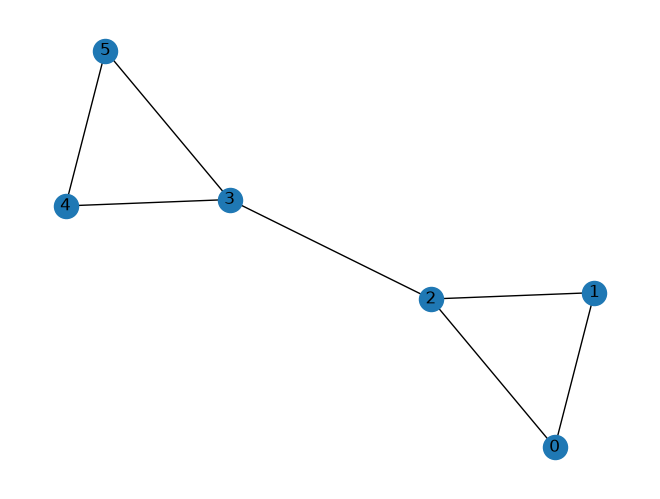

In [19]:
nx.draw(G, with_labels=True)

In [20]:
# List of nodes (vertices) in the graph
nodes = list(G.nodes())

# List of edges in the graph
edges = list(G.edges())
print("Number of edges:", len(edges))

# Build an adjacency dictionary: node -> list of neighboring nodes.
# The graph is undirected, so each edge is added in both directions.
adjacency = dict((node, []) for node in nodes)
for (u, v) in edges:
    adjacency[u].append(v)
    adjacency[v].append(u)

Number of edges: 7


In [21]:
print(nodes)
print(adjacency)

[0, 1, 2, 3, 4, 5]
{0: [1, 2], 1: [0, 2], 2: [0, 1, 3], 3: [2, 4, 5], 4: [3, 5], 5: [3, 4]}


In [22]:
edge_betweenness = brandes(nodes, adjacency)

# The result holds both directions of each edge, e.g. (0,1) and (1,0), 
{(u, v): score for (u, v), score in edge_betweenness.items()
 if score != 0 and u < v}


{(0, 1): 1.0,
 (0, 2): 4.0,
 (1, 2): 4.0,
 (2, 3): 9.0,
 (3, 4): 4.0,
 (3, 5): 4.0,
 (4, 5): 1.0}

In [23]:
nx.edge_betweenness_centrality(G,normalized=False)

{(0, 1): 1.0,
 (0, 2): 4.0,
 (1, 2): 4.0,
 (2, 3): 9.0,
 (3, 4): 4.0,
 (3, 5): 4.0,
 (4, 5): 1.0}

In [24]:
# --- Test cases ---

import networkx as nx

def check_edge(edge_list, n):
    g = nx.Graph()
    g.add_nodes_from(range(n))
    g.add_edges_from(edge_list)
    adjacency = {node: list(g[node]) for node in g.nodes()}
    raw = brandes(list(g.nodes()), adjacency)
    # collapse the two directions into one undirected edge (u < v)
    got = {(u, v): score for (u, v), score in raw.items() if score != 0 and u < v}
    expected = {(min(u, v), max(u, v)): score
                for (u, v), score in nx.edge_betweenness_centrality(g, normalized=False).items()
                if score != 0}
    assert set(got) == set(expected), (set(got), set(expected))
    assert all(abs(got[e] - expected[e]) < 1e-9 for e in expected), (got, expected)

check_edge([(0,1),(0,2),(1,2),(2,3),(3,4),(3,5),(4,5)], 6)  # unique shortest paths
check_edge([(0,1),(1,2),(2,3),(3,0)], 4)                    # 4-cycle (ties)
check_edge([(0,1),(0,2),(1,3),(2,3)], 4)                    # diamond (ties)
check_edge([(0,1),(1,2),(2,3),(3,4),(4,5),(5,0)], 6)        # 6-cycle (ties)
check_edge([(0,1),(0,2),(0,3),(1,2),(1,3),(2,3)], 4)        # K4 (ties)
print("All edge betweenness tests passed.")


All edge betweenness tests passed.
